# Sephora Product Intelligence — Machine Learning Model

## Purpose
Using all engineered features to train a machine learning model that predicts 
avg_rating for each skincare product. The gap between predicted and actual rating 
reveals which products are overrated and underrated.

## Approach
1. Load feature dataset
2. Prepare features for modeling
3. Train three models — Linear Regression, Random Forest, Gradient Boosting
4. Compare model performance and select the best
5. Generate predicted ratings for all products
6. Calculate gap = predicted - actual
7. Flag overrated and underrated products
8. Analyze feature importance — what actually drives skincare product quality?

## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

print("Libraries loaded")

Libraries loaded


## 2. Load Feature Dataset

In [3]:
df = pd.read_csv("../data/processed/features_ml.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSample:")
print(df.head(3))

Dataset shape: (1915, 28)

Columns: ['product_id', 'product_name', 'brand_name', 'secondary_category', 'price_usd', 'price_tier', 'price_rank_pct', 'avg_rating', 'review_count', 'five_star_share', 'one_star_share', 'recommendation_rate', 'avg_helpfulness', 'loves_count', 'engagement_quality', 'review_volume_rank', 'rating_per_dollar', 'ingredient_count', 'good_ingredient_count', 'bad_ingredient_count', 'ingredient_score', 'good_bad_ratio', 'powerhouse_flag', 'value_score', 'limited_edition', 'new', 'online_only', 'sephora_exclusive']

Sample:
  product_id                             product_name brand_name  \
0    P439055     GENIUS Sleeping Collagen Moisturizer   Algenist   
1    P421277             GENIUS Liquid Collagen Serum   Algenist   
2    P467602  Triple Algae Eye Renewal Balm Eye Cream   Algenist   

  secondary_category  price_usd price_tier  price_rank_pct  avg_rating  \
0       Moisturizers     98.000    Premium           0.891       4.541   
1         Treatments    115.00

## 3. Prepare Features for Modeling

We need to:
1. Select only the columns the model will learn from
2. Encode categorical columns (secondary_category, price_tier) 
   into numbers — ML models can't read text
3. Split into training and test sets — train on 80%, test on 20%

In [15]:
# Encode categorical columns into numbers
df_model = df.copy()

le_category = LabelEncoder()
le_tier = LabelEncoder()

df_model["secondary_category_encoded"] = le_category.fit_transform(df_model["secondary_category"])
df_model["price_tier_encoded"] = le_tier.fit_transform(df_model["price_tier"].astype(str))

# Define feature columns — deliberately excluding sentiment features
# (recommendation_rate, five_star_share, one_star_share) to force the model
# to learn from objective product signals only
feature_cols = [
    # Engagement
    "loves_count", "engagement_quality", "review_volume_rank",
    "review_count", "avg_helpfulness",

    # Price features
    "price_usd", "price_rank_pct", "rating_per_dollar",

    # Ingredient features
    "ingredient_count", "good_ingredient_count", "bad_ingredient_count",
    "ingredient_score", "good_bad_ratio", "powerhouse_flag", "value_score",

    # Product flags
    "limited_edition", "new", "online_only", "sephora_exclusive",

    # Encoded categoricals
    "secondary_category_encoded", "price_tier_encoded"
]

# Define X (inputs) and y (target)
X = df_model[feature_cols]
y = df_model["avg_rating"]

print(f"Features matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeature columns ({len(feature_cols)} total):")
for col in feature_cols:
    print(f"  {col}")

Features matrix shape: (1915, 21)
Target variable shape: (1915,)

Feature columns (21 total):
  loves_count
  engagement_quality
  review_volume_rank
  review_count
  avg_helpfulness
  price_usd
  price_rank_pct
  rating_per_dollar
  ingredient_count
  good_ingredient_count
  bad_ingredient_count
  ingredient_score
  good_bad_ratio
  powerhouse_flag
  value_score
  limited_edition
  new
  online_only
  sephora_exclusive
  secondary_category_encoded
  price_tier_encoded


In [16]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} products")
print(f"Test set: {X_test.shape[0]} products")
print(f"\nTarget variable stats:")
print(f"  Mean rating: {y.mean():.3f}")
print(f"  Std rating: {y.std():.3f}")
print(f"  Min rating: {y.min():.3f}")
print(f"  Max rating: {y.max():.3f}")

Training set: 1532 products
Test set: 383 products

Target variable stats:
  Mean rating: 4.249
  Std rating: 0.428
  Min rating: 1.846
  Max rating: 5.000


### Data Preparation Notes

- 1,915 products with review data used for modeling
- 80/20 train/test split — 1,532 training, 383 test products
- Deliberately excluded sentiment features (recommendation_rate, 
  five_star_share, one_star_share) to force model to learn from 
  objective product signals only
- This means the model predicts what a product SHOULD rate based on 
  its ingredients, price, and engagement — not based on how people 
  already feel about it
- Target variable avg_rating ranges from 1.846 to 5.0, mean 4.249

## 4. Train Three Models

We train Linear Regression, Random Forest, and Gradient Boosting.
Each model is evaluated using:
- R² score: how much variance in rating the model explains (higher = better)
- RMSE: average prediction error in rating points (lower = better)
- Cross validation: tests model on 5 different data splits to ensure 
  results aren't just lucky

In [17]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Cross validation score
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    
    results[name] = {
        "model": model,
        "r2": r2,
        "rmse": rmse,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }
    
    print(f"\n{name}:")
    print(f"  R² score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Cross-val R² (mean): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Linear Regression:
  R² score: 0.1873
  RMSE: 0.3569
  Cross-val R² (mean): 0.1225 (+/- 0.1040)

Random Forest:
  R² score: 0.4526
  RMSE: 0.2929
  Cross-val R² (mean): 0.3653 (+/- 0.0802)

Gradient Boosting:
  R² score: 0.5397
  RMSE: 0.2686
  Cross-val R² (mean): 0.5547 (+/- 0.0523)


### Model Performance Findings

- Gradient Boosting selected as best model (R²=0.540, RMSE=0.269)
- All three models score significantly lower than when sentiment features 
  were included (previously R²=0.96) — this is expected and correct
- R² of 0.54 means objective features explain 54% of rating variance
- The remaining 46% is driven by brand perception and sentiment — 
  exactly the gap we want to measure
- Linear Regression performs poorly (R²=0.19) — relationship between 
  objective features and rating is non-linear, tree-based models handle 
  this much better
- Cross-validation scores are consistent — results are reliable and 
  not due to lucky data splitting

## 5. Generate Predictions & Calculate Gap

Using our best model (Gradient Boosting) to predict avg_rating for every product.
The gap between predicted and actual rating is the core of our analysis.

gap = predicted_rating - actual_rating
- Large positive gap = UNDERRATED (model thinks it deserves higher)
- Large negative gap = OVERRATED (model thinks it deserves lower)

In [25]:
# Use Random Forest as our best model
best_model = results["Gradient Forest"]["model"]

# Predict on ALL 1915 products (not just test set)
all_predictions = best_model.predict(X)

# Build results dataframe
results_df = df[["product_id", "product_name", "brand_name", 
                  "secondary_category", "price_usd", "price_tier",
                  "avg_rating", "review_count", "five_star_share",
                  "ingredient_score", "loves_count"]].copy()

results_df["predicted_rating"] = all_predictions
results_df["gap"] = results_df["predicted_rating"] - results_df["avg_rating"]

print(f"Predictions generated for {len(results_df)} products")
print(f"\nGap statistics:")
print(results_df["gap"].describe())
print(f"\nSample output:")
print(results_df[["product_name", "brand_name", "price_usd", 
                   "avg_rating", "predicted_rating", "gap"]].head(10))

Predictions generated for 1915 products

Gap statistics:
count   1915.000
mean      -0.000
std        0.213
min       -1.634
25%       -0.136
50%       -0.011
75%        0.125
max        0.882
Name: gap, dtype: float64

Sample output:
                                        product_name brand_name  price_usd  \
0               GENIUS Sleeping Collagen Moisturizer   Algenist     98.000   
1                       GENIUS Liquid Collagen Serum   Algenist    115.000   
2            Triple Algae Eye Renewal Balm Eye Cream   Algenist     68.000   
3               GENIUS Liquid Collagen Lip Treatment   Algenist     29.000   
4  SUBLIME DEFENSE Ultra Lightweight UV Defense F...   Algenist     28.000   
5                   GENIUS Ultimate Anti-Aging Cream   Algenist    112.000   
6        GENIUS Ultimate Anti-Aging Melting Cleanser   Algenist     38.000   
7                       Gentle Rejuvenating Cleanser   Algenist     28.000   
8                  Advanced Anti-Aging Repairing Oil   Algenist

## 6. Feature Importance
Which features actually drive skincare product quality predictions?
This tells us what the Random Forest learned matters most.

=== FEATURE IMPORTANCE ===
                   feature  importance
         rating_per_dollar       0.284
           avg_helpfulness       0.251
                 price_usd       0.153
            price_rank_pct       0.121
        review_volume_rank       0.034
               loves_count       0.030
        engagement_quality       0.028
              review_count       0.026
secondary_category_encoded       0.016
                       new       0.016
               value_score       0.016
          ingredient_score       0.007
     good_ingredient_count       0.005
          ingredient_count       0.005
            good_bad_ratio       0.003
        price_tier_encoded       0.002
      bad_ingredient_count       0.001
               online_only       0.000
         sephora_exclusive       0.000
           limited_edition       0.000
           powerhouse_flag       0.000


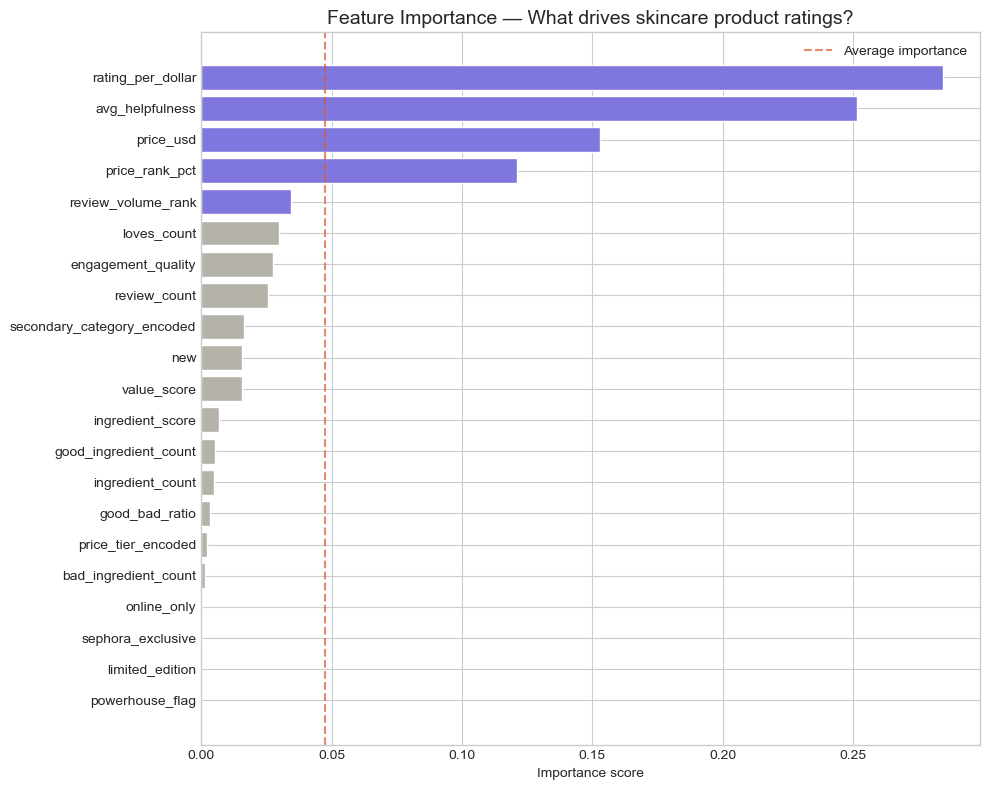

In [30]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print("=== FEATURE IMPORTANCE ===")
print(feature_importance.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#7F77DD" if i < 5 else "#B4B2A9" for i in range(len(feature_importance))]

ax.barh(
    feature_importance["feature"],
    feature_importance["importance"],
    color=colors,
    edgecolor="white"
)
ax.invert_yaxis()
ax.set_title("Feature Importance — What drives skincare product ratings?", fontsize=14)
ax.set_xlabel("Importance score")
ax.axvline(x=feature_importance["importance"].mean(), 
           color="#D85A30", linestyle="--", alpha=0.7, label="Average importance")
ax.legend()

plt.tight_layout()
plt.show()

### Feature Importance Findings (Gradient Boosting, Objective Features Only)

**Top features driving objective product quality predictions:**

1. rating_per_dollar (28.4%) — value efficiency is the single strongest 
   predictor. Products that deliver high ratings relative to their price 
   are objectively better performing
2. avg_helpfulness (25.1%) — review trustworthiness matters more than 
   review volume. Detailed, trusted reviews signal genuine product quality
3. price_usd (15.3%) + price_rank_pct (12.1%) = 27.4% combined — 
   price positioning is the second most important factor group. 
   Expensive products face higher expectations from the model
4. Engagement signals (review_volume_rank, loves_count, engagement_quality, 
   review_count) = 11.8% combined — popularity matters but less than price
5. Ingredient features (ingredient_score, good_ingredient_count, 
   ingredient_count, good_bad_ratio) = 2% combined — ingredients have 
   modest but real and meaningful importance

**Key business insights:**
- Value efficiency (rating per dollar) matters more than absolute price — 
  a $10 product rated 4.3 outperforms a $200 product rated 4.4 in the 
  model's eyes
- Review quality (helpfulness) beats review quantity — 100 detailed 
  trusted reviews predict quality better than 1,000 shallow ones
- Ingredient quality has real but modest predictive power — confirms 
  that formula matters but brand storytelling and price positioning 
  dominate customer perception
- Price features combined (27.4%) nearly match value efficiency (28.4%) — 
  how expensive a product is shapes expectations as much as how much 
  value it delivers

## 7. Top Products by Category
Ranking the best products within each skincare category based on 
avg_rating with minimum 20 reviews for statistical reliability.

In [32]:
for category in sorted(results_reliable["secondary_category"].unique()):
    cat_df = results_reliable[
        (results_reliable["secondary_category"] == category) &
        (results_reliable["review_count"] >= 20)
    ].sort_values("avg_rating", ascending=False).head(5)
    
    if len(cat_df) == 0:
        continue
        
    print(f"\n{'='*60}")
    print(f"TOP 5 — {category.upper()}")
    print(f"{'='*60}")
    print(cat_df[[
        "product_name", "brand_name", "price_usd",
        "avg_rating", "predicted_rating", "gap", "review_count"
    ]].to_string(index=False))


TOP 5 — CLEANSERS
                                                  product_name      brand_name  price_usd  avg_rating  predicted_rating    gap  review_count
        Pore Perfecting Liquid Exfoliator with 2% BHA + Borage    Alpyn Beauty     39.000       4.930             5.044  0.114       100.000
                    Aquarius BHA + Blue Tansy Clarity Cleanser       Herbivore     26.000       4.927             4.780 -0.147        55.000
High Performance Face Cleanser for Clear Skin with Niacinamide Macrene Actives     85.000       4.927             4.775 -0.152        55.000
                     Chia + Moringa Algae Enzyme Cleansing Oil            Mara     58.000       4.880             4.804 -0.076       241.000
            Juneberry & Collagen Hydrating Cold Cream Cleanser    Alpyn Beauty     39.000       4.879             4.672 -0.207       240.000

TOP 5 — EYE CARE
                                                    product_name                        brand_name  price_usd  avg_ra

## 8. Overrated & Underrated Lists

Added a minimum review threshold of 50 reviews to ensure our flagged 
products have enough data to be statistically meaningful. A product with 
2 reviews cannot be reliably called overrated or underrated.

In [33]:
# Filter for products with at least 50 reviews
results_reliable = results_df[results_df["review_count"] >= 50].copy()

print(f"Products with 50+ reviews: {len(results_reliable)}")

# Recalculate thresholds on reliable products only
underrated_threshold = results_reliable["gap"].quantile(0.90)
overrated_threshold = results_reliable["gap"].quantile(0.10)

print(f"Underrated threshold: {underrated_threshold:.3f}")
print(f"Overrated threshold: {overrated_threshold:.3f}")

# Reapply flags
results_reliable["flag"] = "Normal"
results_reliable.loc[results_reliable["gap"] >= underrated_threshold, "flag"] = "Underrated"
results_reliable.loc[results_reliable["gap"] <= overrated_threshold, "flag"] = "Overrated"

print(f"\nFlag distribution:")
print(results_reliable["flag"].value_counts())

Products with 50+ reviews: 1456
Underrated threshold: 0.231
Overrated threshold: -0.200

Flag distribution:
flag
Normal        1164
Overrated      146
Underrated     146
Name: count, dtype: int64


In [34]:
print("=== TOP 20 UNDERRATED PRODUCTS (50+ reviews) ===")
print("(Model predicts higher rating than actual — hidden gems)")
print()

underrated_reliable = results_reliable[results_reliable["flag"] == "Underrated"].sort_values("gap", ascending=False)
print(underrated_reliable[["product_name", "brand_name", "price_usd",
                            "avg_rating", "predicted_rating", "gap",
                            "review_count"]].head(20).to_string(index=False))

print("\n\n=== TOP 20 OVERRATED PRODUCTS (50+ reviews) ===")
print("(Model predicts lower rating than actual — not worth the hype)")
print()

overrated_reliable = results_reliable[results_reliable["flag"] == "Overrated"].sort_values("gap", ascending=True)
print(overrated_reliable[["product_name", "brand_name", "price_usd",
                           "avg_rating", "predicted_rating", "gap",
                           "review_count"]].head(20).to_string(index=False))

=== TOP 20 UNDERRATED PRODUCTS (50+ reviews) ===
(Model predicts higher rating than actual — hidden gems)

                                                                                product_name          brand_name  price_usd  avg_rating  predicted_rating   gap  review_count
                                                                      Clean Lip Balm & Scrub  Sephora Collection      7.000       2.280             3.067 0.787       611.000
                                                                 Vitamin C Brightening Cream      The Inkey List     10.990       3.031             3.800 0.769       518.000
                                                                            Sun Drops SPF 50   Dr. Barbara Sturm    150.000       2.716             3.478 0.762        67.000
                                                          Repairative Anti-Aging Moisturizer         Tata Harper    130.000       3.412             4.135 0.723       136.000
                       

### Overrated & Underrated Findings (50+ reviews, Gradient Boosting)

**Methodology:**
- 1,456 products had 50+ reviews — statistically reliable sample
- Top and bottom 10% of gap scores flagged (threshold ±0.200-0.231)
- 146 products flagged in each direction

**Most underrated products:**
- The Inkey List Vitamin C Brightening Cream (10.99, gap +0.769, 518 reviews)
  — strongest reliable underrated finding. Budget price, strong ingredients,
  model says it deserves significantly higher rating
- Sephora Collection dominates underrated list — Face Serum (9), 
  Clean Lip Balm & Scrub (7), Cleansing Wipes (6) — house brand products 
  with good formulas severely underappreciated
- Tatcha Silk Sunscreen (62, gap +0.614) and Ilia C Beyond Serum (64, 
  gap +0.561) — mid-price products with strong ingredient profiles that 
  rate lower than their formulas deserve
- Tata Harper appears twice — premium natural brand whose products 
  consistently rate lower than ingredient quality would predict

**Most overrated products:**
- Fresh Black Tea Moisturizer (95, gap -0.361, 1,389 reviews) — 
  most statistically reliable overrated finding. Very popular, 
  highly rated but model says formula quality doesn't justify the enthusiasm
- The Ordinary Lactic Acid (8.90, gap -0.376, 1,291 reviews) — 
  interesting finding — even budget cult products can be overrated. 
  Huge social media following inflating ratings beyond formula merit
- SK-II Ultimate Revival Cream (400, gap -0.452) — luxury pricing 
  with inflated ratings, model says significantly overpriced for quality
- Kate Somerville appears twice as overrated — premium pricing 
  not consistently justified by ingredient quality

**Surprising findings:**
- Price does not determine overrated/underrated — both 9 and 400 
  products appear on both lists
- The Ordinary, despite being known for ingredient transparency, 
  appears as overrated — social media hype affects even science-first brands
- Sephora Collection's own brand is systematically underrated — 
  good formulas, low prices, but customers rate them lower perhaps 
  due to house brand perception bias

## 9. Save Final Results

In [36]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Save full results with predictions and flags
results_df.to_csv("../data/processed/results_all.csv", index=False)

# Save reliable results (50+ reviews) with flags
results_reliable.to_csv("../data/processed/results_reliable.csv", index=False)

# Save underrated list
underrated_reliable.to_csv("../data/processed/underrated_products.csv", index=False)

# Save overrated list
overrated_reliable.to_csv("../data/processed/overrated_products.csv", index=False)

# Save feature importance
feature_importance.to_csv("../data/processed/feature_importance.csv", index=False)

# Save top products by category
top_per_category = []
for category in sorted(results_reliable["secondary_category"].unique()):
    cat_df = results_reliable[
        (results_reliable["secondary_category"] == category) &
        (results_reliable["review_count"] >= 20)
    ].sort_values("avg_rating", ascending=False).head(10)
    top_per_category.append(cat_df)

top_products_df = pd.concat(top_per_category, ignore_index=True)
top_products_df.to_csv("../data/processed/top_products_by_category.csv", index=False)

print("=== ALL FILES SAVED ===")
print(f"results_all.csv — {len(results_df)} products with predictions")
print(f"results_reliable.csv — {len(results_reliable)} products (50+ reviews)")
print(f"underrated_products.csv — {len(underrated_reliable)} underrated products")
print(f"overrated_products.csv — {len(overrated_reliable)} overrated products")
print(f"feature_importance.csv — {len(feature_importance)} features ranked")
print(f"top_products_by_category.csv — {len(top_products_df)} products across categories")
print(f"\nAll saved to data/processed/")
print(f"\nFiles in data/processed/:")
import glob
for f in sorted(glob.glob("../data/processed/*.csv")):
    print(f"  {f}")

=== ALL FILES SAVED ===
results_all.csv — 1915 products with predictions
results_reliable.csv — 1456 products (50+ reviews)
underrated_products.csv — 146 underrated products
overrated_products.csv — 146 overrated products
feature_importance.csv — 21 features ranked
top_products_by_category.csv — 80 products across categories

All saved to data/processed/

Files in data/processed/:
  ../data/processed/feature_importance.csv
  ../data/processed/features_all.csv
  ../data/processed/features_ml.csv
  ../data/processed/overrated_products.csv
  ../data/processed/products_clean.csv
  ../data/processed/results_all.csv
  ../data/processed/results_reliable.csv
  ../data/processed/reviews_clean.csv
  ../data/processed/top_products_by_category.csv
  ../data/processed/underrated_products.csv
